# Contextual Multi-Armed Bandit with Zooming Model

This notebook demonstrates the usage of the Zooming model for quantitative action spaces with the contextual multi-armed bandit (CMAB) implementation in `pybandits`.

The Zooming model adaptively partitions a continuous action space and fits a model (e.g., Bayesian Neural Network) to each segment. This allows efficient exploration and exploitation in continuous or high-cardinality action spaces through an adaptive discretization approach. Unlike the SMAB zooming model, the CMAB version uses contextual information to predict rewards.

References:
- [Multi-Armed Bandits in Metric Spaces (Kleinberg, Slivkins, and Upfal, 2008)](https://arxiv.org/pdf/0809.4882)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

from pybandits.cmab import CmabBernoulli
from pybandits.quantitative_model import CmabZoomingModel

/home/runner/.cache/pypoetry/virtualenvs/pybandits-vYJB-miV-py3.10/lib/python3.10/site-packages/pydantic/_migration.py:283: UserWarning: `pydantic.generics:GenericModel` has been moved to `pydantic.BaseModel`.
  warnings.warn(f'`{import_path}` has been moved to `{new_location}`.')


## Setup

First, we'll define actions with quantitative parameters. In this example, we'll use two actions, each with a one-dimensional quantitative parameter (e.g., price point or dosage level) ranging from 0 to 1. Unlike the SMAB model, here we also need to define contextual features.

In [2]:
# For reproducibility
np.random.seed(42)

# Define number of features for the context
n_features = 3
# Define number of segments for each action
n_max_segments = 16  # Maximum number of segments for each action
# Define cold start parameters for the base model
base_model_cold_start_kwargs = {
    "n_features": n_features,  # Number of context features
    "update_method": "VI",  # Variational Inference for Bayesian updates
}


# Define actions with zooming models
actions = {
    "action_1": CmabZoomingModel.cold_start(
        dimension=1, n_max_segments=n_max_segments, base_model_cold_start_kwargs=base_model_cold_start_kwargs
    ),
    "action_2": CmabZoomingModel.cold_start(
        dimension=1, n_max_segments=n_max_segments, base_model_cold_start_kwargs=base_model_cold_start_kwargs
    ),
}

Now we can initialize the CmabBernoulli bandit with our zooming models:

In [3]:
# Initialize the bandit
cmab = CmabBernoulli(actions=actions)

## Simulate Environment

Let's create a reward function that depends on both the action, its quantitative parameter, and the context. For illustration purposes, we'll define that:

- `action_1` performs better when the first context feature is high and when the quantitative parameter is around 0.25
- `action_2` performs better when the second context feature is high and when the quantitative parameter is around 0.75

The reward probability follows a bell curve for the quantitative parameter and is also influenced by the context features.

In [4]:
def reward_function(action, quantity, context):
    if action == "action_1":
        # Bell curve centered at 0.25 for the quantity
        # Influenced by first context feature
        quantity_component = np.exp(-((quantity - 0.25) ** 2) / 0.02)
        context_component = 0.5 + 0.5 * (context[0] / 2)  # First feature has influence
        prob = quantity_component * context_component
    else:  # action_2
        # Bell curve centered at 0.75 for the quantity
        # Influenced by second context feature
        quantity_component = np.exp(-((quantity - 0.75) ** 2) / 0.02)
        context_component = 0.5 + 0.5 * (context[1] / 2)  # Second feature has influence
        prob = quantity_component * context_component

    # Ensure probability is between 0 and 1
    prob = max(0, min(1, prob))

    return np.random.binomial(1, prob)

Let's visualize our reward functions to understand what the bandit needs to learn. We'll show the reward surfaces for different values of context:

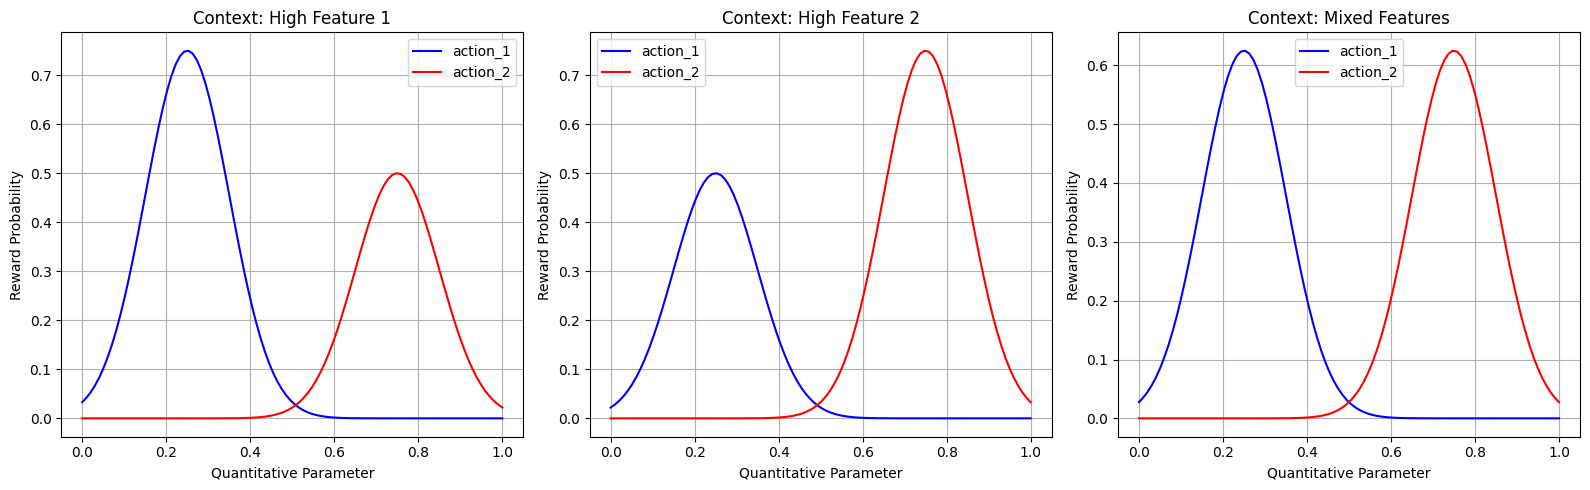

In [5]:
x = np.linspace(0, 1, 100)

# Plot for three different contexts
contexts = [
    np.array([1.0, 0.0, 0.0]),  # High first feature
    np.array([0.0, 1.0, 0.0]),  # High second feature
    np.array([0.5, 0.5, 0.0]),  # Mixed features
]

plt.figure(figsize=(16, 5))
for i, context in enumerate(contexts, 1):
    plt.subplot(1, 3, i)

    y1 = [np.exp(-((xi - 0.25) ** 2) / 0.02) * (0.5 + 0.5 * (context[0] / 2)) for xi in x]
    y2 = [np.exp(-((xi - 0.75) ** 2) / 0.02) * (0.5 + 0.5 * (context[1] / 2)) for xi in x]

    plt.plot(x, y1, "b-", label="action_1")
    plt.plot(x, y2, "r-", label="action_2")
    plt.xlabel("Quantitative Parameter")
    plt.ylabel("Reward Probability")

    if i == 1:
        title = "Context: High Feature 1"
    elif i == 2:
        title = "Context: High Feature 2"
    else:
        title = "Context: Mixed Features"

    plt.title(title)
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

## Generate Synthetic Context Data

Let's create synthetic context data for our experiment:

In [6]:
# Generate random context data
n_batches = 10
batch_size = 100
n_rounds = n_batches * batch_size
raw_context_data = np.random.normal(0, 1, (n_rounds, n_features))

# Standardize the context data
scaler = StandardScaler()
context_data = scaler.fit_transform(raw_context_data)

# Preview the context data
pd.DataFrame(context_data[:5], columns=[f"Feature {i + 1}" for i in range(n_features)])

,Feature 1,Feature 2,Feature 3
0,0.455492,-0.131237,0.612596
1,1.513847,-0.226359,-0.286650
2,1.571784,0.767215,-0.526636
3,0.502769,-0.453789,-0.522818
4,0.192787,-1.892050,-1.806881


## Bandit Training Loop

Now, let's train our bandit by simulating interactions for several rounds:

In [7]:
for t in range(n_batches):
    # Get context for this round
    current_context = context_data[t * batch_size : (t + 1) * batch_size]

    # Predict best action
    pred_actions, probs, weighted_sums = cmab.predict(context=current_context)
    chosen_actions = [a[0] for a in pred_actions]
    chosen_quantities = [a[1][0] for a in pred_actions]

    # Observe reward
    rewards = [
        reward_function(chosen_action, chosen_quantity, current_context[0])
        for chosen_action, chosen_quantity in zip(chosen_actions, chosen_quantities)
    ]

    # Update bandit
    cmab.update(actions=chosen_actions, rewards=rewards, context=current_context, quantities=chosen_quantities)

    # Print progress
    print(f"Completed {t} batches")

/home/runner/.cache/pypoetry/virtualenvs/pybandits-vYJB-miV-py3.10/lib/python3.10/site-packages/pymc/data.py:384: FutureWarning: Data is now always mutable. Specifying the `mutable` kwarg will raise an error in a future release
  warnings.warn(


/home/runner/.cache/pypoetry/virtualenvs/pybandits-vYJB-miV-py3.10/lib/python3.10/site-packages/pytensor/link/c/cmodule.py:2968: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Sampling: [bias_0, out, weight_0]


/home/runner/.cache/pypoetry/virtualenvs/pybandits-vYJB-miV-py3.10/lib/python3.10/site-packages/pymc/data.py:384: FutureWarning: Data is now always mutable. Specifying the `mutable` kwarg will raise an error in a future release
  warnings.warn(
Sampling: [bias_0, out, weight_0]


/home/runner/.cache/pypoetry/virtualenvs/pybandits-vYJB-miV-py3.10/lib/python3.10/site-packages/pymc/data.py:384: FutureWarning: Data is now always mutable. Specifying the `mutable` kwarg will raise an error in a future release
  warnings.warn(


Sampling: [bias_0, out, weight_0]


...

Finished [100%]: Average Loss = 8.6282


/home/runner/.cache/pypoetry/virtualenvs/pybandits-vYJB-miV-py3.10/lib/python3.10/site-packages/pymc/data.py:384: FutureWarning: Data is now always mutable. Specifying the `mutable` kwarg will raise an error in a future release
  warnings.warn(


/home/runner/.cache/pypoetry/virtualenvs/pybandits-vYJB-miV-py3.10/lib/python3.10/site-packages/rich/live.py:231: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Finished [100%]: Average Loss = 209.35


Completed 9 batches


## Examining Segment Adaptation

Let's look at the adaptive segmentation for one of the actions to see how the model has split the quantitative space:

Number of segments for action_1: 16
Number of segments for action_2: 6


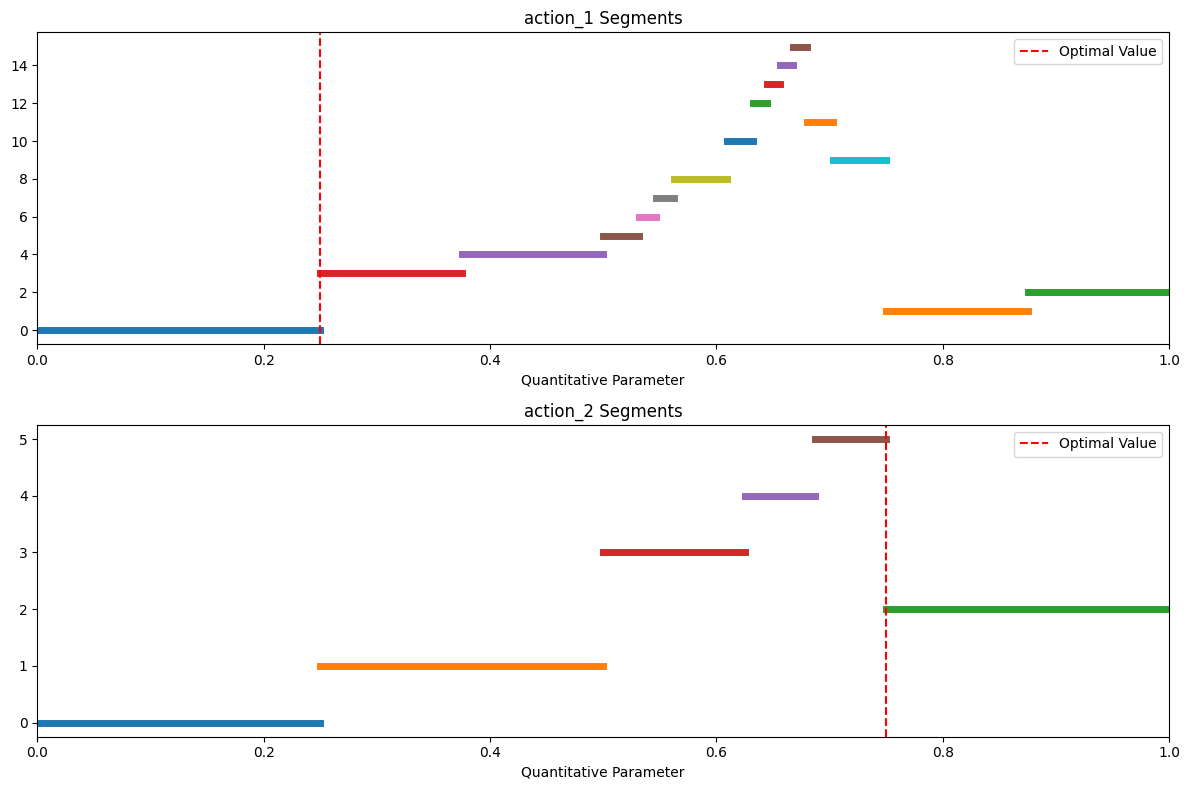

In [8]:
# Extract the segmentation for one of the actions
action1_segments = list(cmab.actions["action_1"].segmented_actions.keys())
action2_segments = list(cmab.actions["action_2"].segmented_actions.keys())

# Print the number of segments
print(f"Number of segments for action_1: {len(action1_segments)}")
print(f"Number of segments for action_2: {len(action2_segments)}")

# Create a figure to visualize the segments
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot action_1 segments
ax1.set_title("action_1 Segments")
for i, segment in enumerate(action1_segments):
    ax1.plot([segment.mins[0], segment.maxs[0]], [i, i], linewidth=5)
ax1.set_xlim(0, 1)
ax1.set_xlabel("Quantitative Parameter")
ax1.axvline(0.25, color="red", linestyle="--", label="Optimal Value")
ax1.legend()

# Plot action_2 segments
ax2.set_title("action_2 Segments")
for i, segment in enumerate(action2_segments):
    ax2.plot([segment.mins[0], segment.maxs[0]], [i, i], linewidth=5)
ax2.set_xlim(0, 1)
ax2.set_xlabel("Quantitative Parameter")
ax2.axvline(0.75, color="red", linestyle="--", label="Optimal Value")
ax2.legend()

plt.tight_layout()
plt.show()

## Testing with Specific Contexts

Finally, let's test our trained bandit with specific contexts to see if it has learned the optimal policy:

In [9]:
# Define test contexts
test_contexts = [
    [2.0, -1.0, 0.0],  # High feature 1, low feature 2
    [-1.0, 2.0, 0.0],  # Low feature 1, high feature 2
    [1.0, 1.0, 0.0],  # High feature 1 and 2
    [-1.0, -1.0, 0.0],  # Low feature 1 and 2
]
test_contexts = scaler.transform(test_contexts)

# Test predictions
results = []
for i, context in enumerate(test_contexts):
    context_reshaped = context.reshape(1, -1)
    pred_actions, probs, weighted_sums = cmab.predict(context=context_reshaped)
    chosen_action_quantity = pred_actions[0]
    chosen_action_probs = {action: probs[0][chosen_action_quantity] for action in actions}
    chosen_action = chosen_action_quantity[0]
    chosen_quantities = chosen_action_quantity[1][0]
    chosen_action_probs = probs[0][chosen_action_quantity]

    # Sample optimal quantity for the chosen action
    # In a real application, you would have a method to test different quantities
    # Here we'll use our knowledge of the true optimal values
    if chosen_action == "action_1":
        optimal_quantity = 0.25
    else:
        optimal_quantity = 0.75

    # Expected reward probability
    expected_reward = reward_function(chosen_action, optimal_quantity, context)

    results.append(
        {
            "Context": context,
            "Chosen Action": chosen_action,
            "Action Probabilities": chosen_action_probs,
            "Optimal Quantity": optimal_quantity,
            "Expected Reward": expected_reward,
        }
    )

# Display results
for i, result in enumerate(results):
    context_type = ""
    if i == 0:
        context_type = "High feature 1, low feature 2"
    elif i == 1:
        context_type = "Low feature 1, high feature 2"
    elif i == 2:
        context_type = "High feature 1 and 2"
    elif i == 3:
        context_type = "Low feature 1 and 2"

    print(f"\nTest {i + 1}: {context_type}")
    print(f"Context: {result['Context']}")
    print(f"Chosen Action: {result['Chosen Action']}")
    print(f"Action Probabilities: {result['Action Probabilities']}")
    print(f"Optimal Quantity: {result['Optimal Quantity']:.2f}")
    print(f"Expected Reward: {result['Expected Reward']}")

/home/runner/.cache/pypoetry/virtualenvs/pybandits-vYJB-miV-py3.10/lib/python3.10/site-packages/pymc/data.py:384: FutureWarning: Data is now always mutable. Specifying the `mutable` kwarg will raise an error in a future release
  warnings.warn(


Sampling: [bias_0, out, weight_0]


/home/runner/.cache/pypoetry/virtualenvs/pybandits-vYJB-miV-py3.10/lib/python3.10/site-packages/pymc/data.py:384: FutureWarning: Data is now always mutable. Specifying the `mutable` kwarg will raise an error in a future release
  warnings.warn(
Sampling: [bias_0, out, weight_0]


/home/runner/.cache/pypoetry/virtualenvs/pybandits-vYJB-miV-py3.10/lib/python3.10/site-packages/pymc/data.py:384: FutureWarning: Data is now always mutable. Specifying the `mutable` kwarg will raise an error in a future release
  warnings.warn(


Sampling: [bias_0, out, weight_0]


...

Sampling: [bias_0, out, weight_0]


/home/runner/.cache/pypoetry/virtualenvs/pybandits-vYJB-miV-py3.10/lib/python3.10/site-packages/pymc/data.py:384: FutureWarning: Data is now always mutable. Specifying the `mutable` kwarg will raise an error in a future release
  warnings.warn(
Sampling: [bias_0, out, weight_0]


/home/runner/.cache/pypoetry/virtualenvs/pybandits-vYJB-miV-py3.10/lib/python3.10/site-packages/pymc/data.py:384: FutureWarning: Data is now always mutable. Specifying the `mutable` kwarg will raise an error in a future release
  warnings.warn(


Sampling: [bias_0, out, weight_0]



Test 1: High feature 1, low feature 2
Context: [ 2.0057076  -0.98607779 -0.04788771]
Chosen Action: action_2
Action Probabilities: 1.0
Optimal Quantity: 0.75
Expected Reward: 0

Test 2: Low feature 1, high feature 2
Context: [-1.08794635  1.98991796 -0.04788771]
Chosen Action: action_2
Action Probabilities: 0.9984047627830219
Optimal Quantity: 0.75
Expected Reward: 1

Test 3: High feature 1 and 2
Context: [ 0.97448962  0.99791938 -0.04788771]
Chosen Action: action_2
Action Probabilities: 0.9999136850879772
Optimal Quantity: 0.75
Expected Reward: 1

Test 4: Low feature 1 and 2
Context: [-1.08794635 -0.98607779 -0.04788771]
Chosen Action: action_1
Action Probabilities: 0.9999999998014053
Optimal Quantity: 0.25
Expected Reward: 0


## Conclusion

The CMAB Zooming model extends the concept of adaptive discretization to contextual bandits. This approach allows efficient exploration and exploitation of continuous action parameters while taking context into account. It adaptively refines the segmentation of the parameter space, concentrating more segments in high-reward regions for finer discretization.

This approach is particularly useful when:
1. Actions have continuous parameters that affect rewards
2. The reward function depends on both context and action parameters
3. The optimal parameter values may vary across different contexts
4. The action space needs to be adaptively discretized for efficient exploration

Real-world applications include:
- Personalized pricing: Find optimal prices (continuous parameter) based on customer features (context)
- Content recommendation: Optimize content parameters (e.g., length, complexity) based on user demographics
- Medical dosing: Determine optimal medication dosages based on patient characteristics
- Ad campaign optimization: Find best bid values based on ad placement and target audience